# **Principal Component Analysis Using Sklearn**

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 3000

rooms = np.random.randint(1, 7, n)

washrooms = []
for r in rooms:
    washrooms.append(max(1, r // 2 + np.random.randint(0, 3)))

washrooms = np.array(washrooms)


location_score = np.random.randint(1, 14, n)

price_lakhs = (
     location_score * 1
    + washrooms * 3
     + rooms * 10
    + np.random.normal(0, 10, n)
)

df = pd.DataFrame({
    "rooms": rooms,
    "washrooms": washrooms,
    "location_score": location_score,
    "price_lakhs": price_lakhs.round(2)
})

In [2]:
df.head()

,rooms,washrooms,location_score,price_lakhs
0,4,2,10,63.26
1,5,2,7,64.37
2,3,2,13,61.28
3,5,2,4,59.88
4,5,3,12,88.76


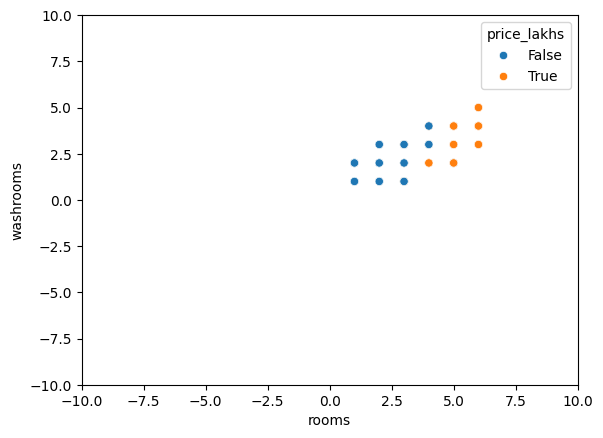

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
threshold = df['price_lakhs'].mean()
sns.scatterplot(
    data=df,
    x='rooms',
    y='washrooms',
    hue=df['price_lakhs'] > threshold
)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()
# We see less points due to the dimension reduction

In [4]:
# Now implementing PCA using sklearn
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca.fit(df[['rooms','washrooms','location_score']])
df_pca=pca.transform(df[['rooms','washrooms','location_score']])
df_pca=pd.DataFrame(df_pca,columns=['PC1','PC2'])
df_pca.head()

,PC1,PC2
0,2.974664,0.079793
1,-0.007439,0.996722
2,5.956767,-0.837136
3,-3.006884,1.054171
4,4.999939,1.411785


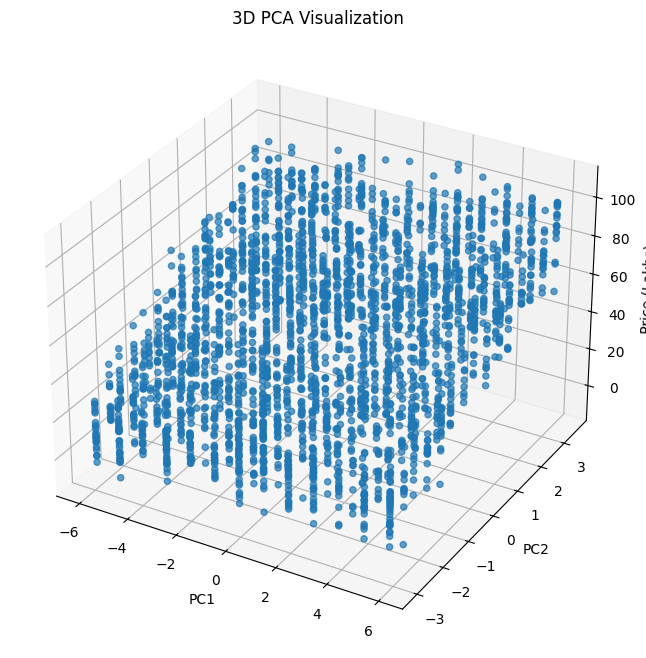

In [15]:
import matplotlib.pyplot as plt

threshold = df['price_lakhs'].mean()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    df['price_lakhs'],
    alpha=0.7
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('Price (Lakhs)')
ax.set_title('3D PCA Visualization')

plt.show()

In [9]:
# Now doing 1D PCA
pca=PCA(n_components=1)
pca.fit(df[['rooms','washrooms','location_score']])
df_pca_1=pca.transform(df[['rooms','washrooms','location_score']])
df_pca_1=pd.DataFrame(df_pca,columns=['PC1'])
df_pca_1.head()

,PC1
0,2.974664
1,-0.007439
2,5.956767
3,-3.006884
4,4.999939


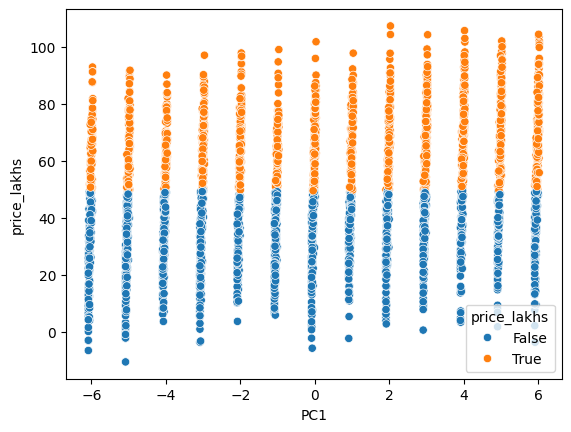

In [13]:
# Ploting pca1 vs prices
sns.scatterplot(
    data=df_pca_1,
    x='PC1',
    y=df['price_lakhs'],
    hue=df['price_lakhs'] > df['price_lakhs'].mean())
plt.show()